# Single Star Dispersion Demo

This notebook demonstrates how to disperse a single star through the Roman grism using wavelength-dependent PSFs.

We'll:
1. Load cached PSF payloads for orders 0 and 1 (order 2 reuses order 1 PSFs)
2. Create a stellar spectrum with wavelength-dependent flux
3. Disperse the star through all orders (0, 1, 2) using `disperse_star_psf()`
4. Visualize the dispersed spectrum on the detector
5. Compare with trace predictions from the optical model

**Key Concept**: Unlike galaxy dispersion (which uses bilinear scatter), star dispersion deposits 
wavelength-dependent PSFs along the spectral trace. Each wavelength has a slightly different PSF shape,
and the PSF is deposited at the dispersed position predicted by the optical model.

**Orders**:
- **Order 0**: Zeroth order (undispersed) - all wavelengths land at the same position
- **Order 1**: First order (primary dispersed spectrum)
- **Order 2**: Second order (uses Order 1 PSFs - same grism optical path)

In [1]:
# Imports
import os
from pathlib import Path
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.patches import Rectangle
import jax
import jax.numpy as jnp

from roman_disperser.optical_model import RomanOpticalModel
import roman_disperser.optical_model_jax as omj
import roman_disperser.star_disperser as star_disperser
import roman_disperser.psf_model as psf_model
import roman_disperser.demo_utils as demo_utils

# Use larger fonts for better readability
plt.rcParams['font.size'] = 11

## Configuration

Set the key parameters for the simulation.

In [2]:
# ============================================================================
# CONFIGURATION - Modify these parameters as needed
# ============================================================================

# Detector and spectral order
DETECTOR = 'WFI05'               # Central detector
SCA = 5                          # SCA number (1-18)

# Orders to disperse (0=zeroth/undispersed, 1=first, 2=second)
# Note: Order 2 uses Order 1 PSFs (similar optical path)
ORDERS = ['0', '1', '2']

# Star position on detector (SCA pixels, FITS 1-indexed)
X_STAR = 2000.0                  # X position of star
Y_STAR = 2000.0                  # Y position of star

# Spectral parameters (wavelengths in microns)
# Using full PSF cache range (0.9-2.0 microns)
LAM_MIN = 0.9                    # Minimum wavelength (microns)
LAM_MAX = 2.0                    # Maximum wavelength (microns)
N_WAVELENGTH = 5000              # Number of wavelength samples (5000 for smooth trace)

# PSF cache directory (set to None to generate fresh PSFs - SLOW!)
PSF_CACHE_DIR = 'data/psf_cache'

print(f"Configuration:")
print(f"  Detector: {DETECTOR} (SCA {SCA})")
print(f"  Orders: {ORDERS}")
print(f"  Star position: ({X_STAR:.1f}, {Y_STAR:.1f}) SCA pixels")
print(f"  Spectrum: {N_WAVELENGTH} samples from {LAM_MIN:.2f}-{LAM_MAX:.2f} microns")
print(f"  Wavelength spacing: {(LAM_MAX - LAM_MIN) / (N_WAVELENGTH - 1) * 1000:.2f} nm")

Configuration:
  Detector: WFI05 (SCA 5)
  Orders: ['0', '1', '2']
  Star position: (2000.0, 2000.0) SCA pixels
  Spectrum: 5000 samples from 0.90-2.00 microns
  Wavelength spacing: 0.22 nm


## Load Optical Model and PSF Payload

In [3]:
# Load optical model
project_root = Path(os.environ.get("PIXI_PROJECT_ROOT", "."))
config_path = project_root / "data" / "Roman_grism_OpticalModel_v0.8.yaml"

model = RomanOpticalModel(config_file=str(config_path))
pixel_scale = model.detmod["pixel_scale"]
print(f"Loaded optical model from {config_path.name}")
print(f"  Pixel scale: {pixel_scale} arcsec/pixel")

Loaded optical model from Roman_grism_OpticalModel_v0.8.yaml
  Pixel scale: 0.11 arcsec/pixel


In [4]:
# Create optical model payloads for all orders
optical_payloads = {}
for order in ORDERS:
    optical_payloads[order] = omj.make_sca_payload(model, sca=SCA, order=order)
    print(f"Created optical payload for SCA {SCA}, order {order}")

Created optical payload for SCA 5, order 0
Created optical payload for SCA 5, order 1
Created optical payload for SCA 5, order 2


In [5]:
# Load PSF payloads (from cache if available)
# Note: Order 2 uses Order 1 PSFs (similar optical path through grism)
cache_dir = project_root / PSF_CACHE_DIR if PSF_CACHE_DIR else None

psf_payloads = {}
psf_orders_to_load = ['0', '1']  # Only need these two; order 2 reuses order 1

print("Loading PSF payloads...")
t0 = time.time()

for order in psf_orders_to_load:
    # Map STPSF filter names
    stpsf_order = order  # '0' -> GRISM0, '1' -> GRISM1
    
    try:
        psf_payloads[order] = psf_model.get_or_make_psf_payload(
            detector=DETECTOR,
            order=stpsf_order,
            cache_dir=str(cache_dir) if cache_dir else None,
            verbose=True,
        )
        print(f"  Order {order}: Grid shape {psf_payloads[order]['psf_grid'].shape}")
    except FileNotFoundError:
        print(f"\nNo cached PSF found for order {order}")
        print("To generate PSF cache, run:")
        print(f"  pixi run python scripts/generate_psf_caches.py --detectors {DETECTOR} --orders {order}")
        raise

# Order 2 uses Order 1 PSFs
psf_payloads['2'] = psf_payloads['1']
print(f"  Order 2: Using Order 1 PSFs (same grism optical path)")

elapsed = time.time() - t0
print(f"\nPSF payloads loaded in {elapsed:.2f} seconds")

Loading PSF payloads...
Loading PSF payload from cache: /Users/np274/10-Notebook/1-Projects/roman_disperser/data/psf_cache/psf_WFI05_GRISM0_4x4x56_0.90-2.00um_fov5.0_os4.npz


/Users/np274/10-Notebook/1-Projects/roman_disperser/.pixi/envs/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded PSF cache: /Users/np274/10-Notebook/1-Projects/roman_disperser/data/psf_cache/psf_WFI05_GRISM0_4x4x56_0.90-2.00um_fov5.0_os4.npz
  Detector: WFI05, Order: 0
  Grid shape: (4, 4, 56, 184, 184)
  Memory: 121.3 MB
  Order 0: Grid shape (4, 4, 56, 184, 184)
Loading PSF payload from cache: /Users/np274/10-Notebook/1-Projects/roman_disperser/data/psf_cache/psf_WFI05_GRISM1_4x4x56_0.90-2.00um_fov5.0_os4.npz
Loaded PSF cache: /Users/np274/10-Notebook/1-Projects/roman_disperser/data/psf_cache/psf_WFI05_GRISM1_4x4x56_0.90-2.00um_fov5.0_os4.npz
  Detector: WFI05, Order: 1
  Grid shape: (4, 4, 56, 184, 184)
  Memory: 121.3 MB
  Order 1: Grid shape (4, 4, 56, 184, 184)
  Order 2: Using Order 1 PSFs (same grism optical path)

PSF payloads loaded in 1.68 seconds


## Create Stellar Spectrum

Create a spectrum with a linear slope (blue to red) and edge roll-off.
This makes the wavelength extent clearly visible in the dispersed images.

The spectrum increases from blue to red with a factor of 3 variation (0.5→1.5),
and smoothly rolls off to zero over 20% of the wavelength range at each edge.

**Note:** We use 5000 wavelength samples (~0.2 nm spacing) to produce a smooth 
dispersed trace. The memory-efficient chunked implementation keeps peak GPU memory
at ~620 MB regardless of wavelength count (processes 1000 wavelengths per chunk).

Spectrum:
  Wavelength range: 0.900 - 2.000 microns
  Wavelength spacing: 0.000220 microns
  Total flux: 4000.400635
  Peak flux: 1.303266


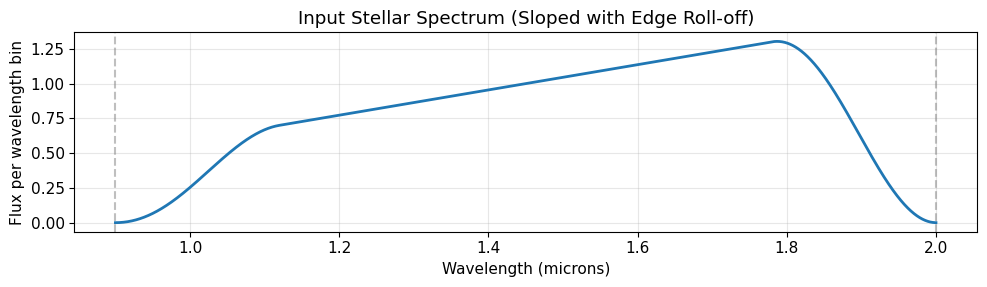

In [6]:
# Create sloped spectrum with edge roll-off
spectrum, lam0, dlam = demo_utils.make_sloped_spectrum(
    lam_min=LAM_MIN,
    lam_max=LAM_MAX,
    n_wavelength=N_WAVELENGTH,
    slope_min=0.5,      # Blue end flux
    slope_max=1.5,      # Red end flux (factor of 3 variation)
    taper_fraction=0.2, # 20% edge roll-off
)

# Convert to JAX array
star_flux = jnp.array(spectrum)
wavelengths = jnp.array(lam0 + np.arange(N_WAVELENGTH) * dlam)

print(f"Spectrum:")
print(f"  Wavelength range: {float(wavelengths[0]):.3f} - {float(wavelengths[-1]):.3f} microns")
print(f"  Wavelength spacing: {dlam:.6f} microns")
print(f"  Total flux: {float(star_flux.sum()):.6f}")
print(f"  Peak flux: {float(star_flux.max()):.6f}")

# Visualize spectrum
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(wavelengths, star_flux, '-', linewidth=2)
ax.axvline(float(wavelengths[0]), color='gray', linestyle='--', alpha=0.5)
ax.axvline(float(wavelengths[-1]), color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Wavelength (microns)')
ax.set_ylabel('Flux per wavelength bin')
ax.set_title('Input Stellar Spectrum (Sloped with Edge Roll-off)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Disperse the Star

Use `make_star_disperser()` to create a JIT-compiled disperser, then disperse the star.

In [7]:
# Create JIT-compiled dispersers for each order
print("Creating star dispersers for each order...")
star_dispersers = {}
for order in ORDERS:
    star_dispersers[order] = star_disperser.make_star_disperser(
        psf_payloads[order], 
        optical_payloads[order]
    )
    print(f"  Order {order}: disperser created")

# Order efficiencies (relative to first order)
# These are simplified placeholders - real values depend on grism design
ORDER_EFFICIENCY = {
    '0': 0.02,   # Zeroth order: 2% of first order
    '1': 1.00,   # First order: 100% (reference)
    '2': 0.01,   # Second order: 1% of first order
}
print(f"\nOrder efficiencies: {ORDER_EFFICIENCY}")

# Initialize output detector
output = jnp.zeros((4088, 4088), dtype=jnp.float32)

# Disperse through all orders
print("\nDispersing star through all orders (first call includes JIT compilation)...")
t0 = time.time()

for order in ORDERS:
    t_order = time.time()
    efficiency = ORDER_EFFICIENCY[order]
    output = star_dispersers[order](
        X_STAR, Y_STAR,
        wavelengths,
        star_flux * efficiency,  # Scale flux by order efficiency
        output
    )
    output.block_until_ready()
    print(f"  Order {order} (eff={efficiency:.0%}): {time.time() - t_order:.3f} seconds")

elapsed_first = time.time() - t0
print(f"Total first call: {elapsed_first:.3f} seconds")

# Second call uses cached compilation
output2 = jnp.zeros((4088, 4088), dtype=jnp.float32)
t0 = time.time()

for order in ORDERS:
    efficiency = ORDER_EFFICIENCY[order]
    output2 = star_dispersers[order](
        X_STAR, Y_STAR,
        wavelengths,
        star_flux * efficiency,
        output2
    )
output2.block_until_ready()

elapsed_cached = time.time() - t0
print(f"Cached call: {elapsed_cached:.3f} seconds")
print(f"Speedup: {elapsed_first/elapsed_cached:.1f}x")

# Check flux conservation
total_efficiency = sum(ORDER_EFFICIENCY.values())
input_flux = float(star_flux.sum()) * total_efficiency
output_flux = float(output.sum())
conservation = 100 * output_flux / input_flux

print(f"\nFlux conservation (all orders):")
print(f"  Input flux: {input_flux:.6f} (sum of efficiencies = {total_efficiency:.0%})")
print(f"  Output flux: {output_flux:.6f}")
print(f"  Conservation: {conservation:.2f}%")

Creating star dispersers for each order...
  Order 0: disperser created
  Order 1: disperser created
  Order 2: disperser created

Order efficiencies: {'0': 0.02, '1': 1.0, '2': 0.01}

Dispersing star through all orders (first call includes JIT compilation)...
  Order 0 (eff=2%): 1.605 seconds
  Order 1 (eff=100%): 1.532 seconds
  Order 2 (eff=1%): 1.564 seconds
Total first call: 4.701 seconds
Cached call: 1.572 seconds
Speedup: 3.0x

Flux conservation (all orders):
  Input flux: 4120.412654 (sum of efficiencies = 103%)
  Output flux: 3989.455078
  Conservation: 96.82%


## Visualize Dispersed Star

In [8]:
# Find the dispersed extent
nonzero = output > output.max() * 1e-6
y_indices, x_indices = jnp.where(nonzero)

if len(y_indices) > 0:
    y_min, y_max = int(y_indices.min()), int(y_indices.max())
    x_min, x_max = int(x_indices.min()), int(x_indices.max())
else:
    y_min, y_max = 0, 4087
    x_min, x_max = 0, 4087

# Add padding
pad = 50
y_min = max(0, y_min - pad)
y_max = min(4087, y_max + pad)
x_min = max(0, x_min - pad)
x_max = min(4087, x_max + pad)

print(f"Dispersed extent: x=[{x_min}, {x_max}], y=[{y_min}, {y_max}]")
print(f"  Y span: {y_max - y_min} pixels")
print(f"  X span: {x_max - x_min} pixels")

Dispersed extent: x=[1825, 2070], y=[383, 4087]
  Y span: 3704 pixels
  X span: 245 pixels


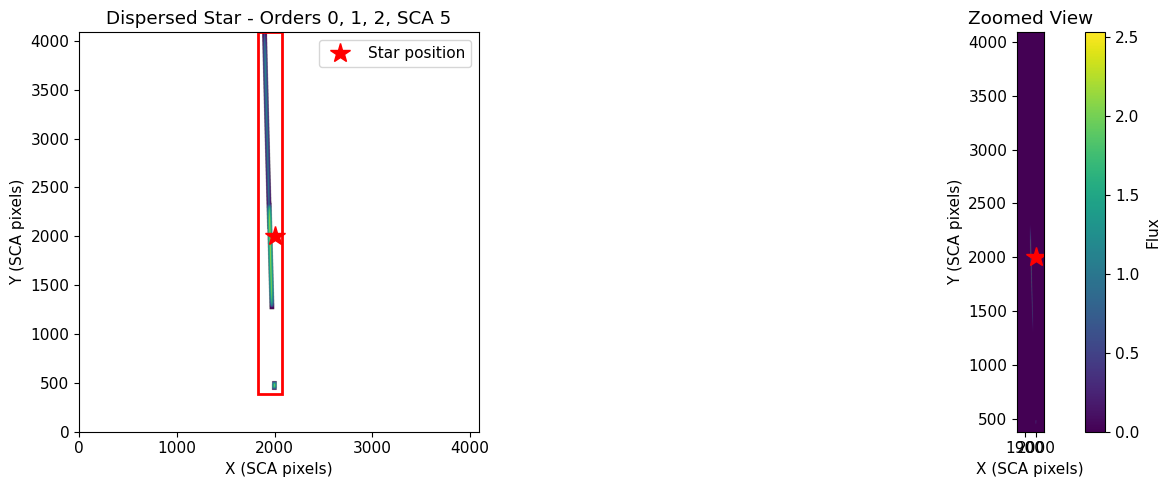

In [9]:
# Create figure with full and zoomed views
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full detector view
ax = axes[0]
im = ax.imshow(
    output,
    origin='lower',
    cmap='viridis',
    norm=LogNorm(vmin=max(1e-10, output.max() * 1e-6), vmax=output.max()),
)
ax.set_title(f'Dispersed Star - Orders {", ".join(ORDERS)}, SCA {SCA}')
ax.set_xlabel('X (SCA pixels)')
ax.set_ylabel('Y (SCA pixels)')

# Draw zoom box
rect = Rectangle(
    (x_min, y_min),
    x_max - x_min,
    y_max - y_min,
    fill=False,
    edgecolor='red',
    linewidth=2,
)
ax.add_patch(rect)

# Mark star position
ax.plot(X_STAR, Y_STAR, 'r*', markersize=15, label='Star position')
ax.legend()

# Zoomed view
ax = axes[1]
zoomed = output[y_min:y_max+1, x_min:x_max+1]
im = ax.imshow(
    zoomed,
    origin='lower',
    cmap='viridis',
    extent=[x_min, x_max, y_min, y_max],
)
ax.set_title(f'Zoomed View')
ax.set_xlabel('X (SCA pixels)')
ax.set_ylabel('Y (SCA pixels)')

# Mark star position
ax.plot(X_STAR, Y_STAR, 'r*', markersize=15)

plt.colorbar(im, ax=ax, label='Flux')
plt.tight_layout()
plt.show()

## Compare with Optical Model Trace

Verify that the dispersed PSFs land at the positions predicted by `trace_beam()`.

In [10]:
# Compute trace positions from optical model for all orders
traces = {}

for order in ORDERS:
    xfpa, yfpa = omj.sca_to_fpa(optical_payloads[order], jnp.array([X_STAR]), jnp.array([Y_STAR]))
    
    # Wavelengths are already in microns (trace_beam expects microns)
    xmpa, ympa = omj.trace_beam(optical_payloads[order], xfpa, yfpa, wavelengths)
    xsca_trace, ysca_trace = omj.mpa_to_sca(optical_payloads[order], xmpa, ympa)
    
    # Flatten to 1D
    traces[order] = {
        'x': xsca_trace.reshape(-1),
        'y': ysca_trace.reshape(-1),
    }
    
    print(f"Order {order} trace:")
    print(f"  X range: {float(traces[order]['x'].min()):.1f} - {float(traces[order]['x'].max()):.1f} pixels")
    print(f"  Y range: {float(traces[order]['y'].min()):.1f} - {float(traces[order]['y'].max()):.1f} pixels")

Order 0 trace:
  X range: 1996.8 - 1998.6 pixels
  Y range: 454.6 - 496.9 pixels
Order 1 trace:
  X range: 1944.8 - 1972.0 pixels
  Y range: 1278.8 - 2320.2 pixels
Order 2 trace:
  X range: 1895.8 - 1948.2 pixels
  Y range: 2097.0 - 4116.0 pixels


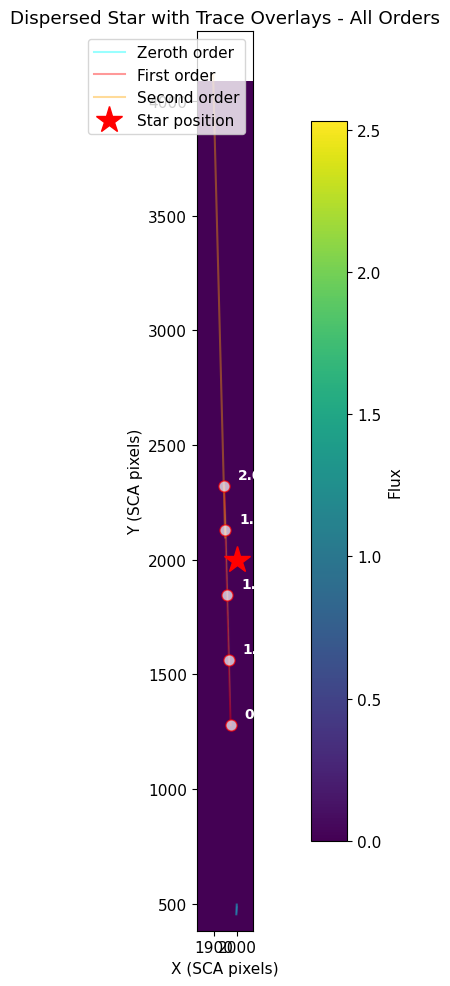

In [11]:
# Plot zoomed view with trace overlay for all orders
fig, ax = plt.subplots(figsize=(12, 10))

zoomed = output[y_min:y_max+1, x_min:x_max+1]
im = ax.imshow(
    zoomed,
    origin='lower',
    cmap='viridis',
    extent=[x_min, x_max, y_min, y_max],
)

# Colors for each order
order_colors = {'0': 'cyan', '1': 'red', '2': 'orange'}
order_labels = {'0': 'Zeroth order', '1': 'First order', '2': 'Second order'}

# Overlay trace positions for each order (high transparency to see underlying data)
for order in ORDERS:
    color = order_colors[order]
    ax.plot(traces[order]['x'], traces[order]['y'], '-', 
            color=color, linewidth=1.5, alpha=0.4, label=order_labels[order])

# Mark specific wavelengths on first order trace only (to avoid clutter)
for i, wl_um in enumerate([0.9, 1.2, 1.5, 1.8, 2.0]):
    idx = int((wl_um - wavelengths[0]) / (wavelengths[-1] - wavelengths[0]) * (N_WAVELENGTH - 1))
    idx = max(0, min(idx, N_WAVELENGTH - 1))
    ax.plot(traces['1']['x'][idx], traces['1']['y'][idx], 'wo', markersize=8, markeredgecolor='red', alpha=0.7)
    ax.annotate(
        f'{wl_um:.1f}',
        (float(traces['1']['x'][idx]), float(traces['1']['y'][idx])),
        textcoords='offset points',
        xytext=(10, 5),
        fontsize=10,
        color='white',
        fontweight='bold',
    )

# Mark star position
ax.plot(X_STAR, Y_STAR, 'r*', markersize=20, label='Star position')

ax.set_title(f'Dispersed Star with Trace Overlays - All Orders')
ax.set_xlabel('X (SCA pixels)')
ax.set_ylabel('Y (SCA pixels)')
ax.legend(loc='upper right')

plt.colorbar(im, ax=ax, label='Flux', shrink=0.8)
plt.tight_layout()
plt.show()

## Cross-Section Analysis

Examine the cross-dispersion profile to see the PSF shape along the trace.

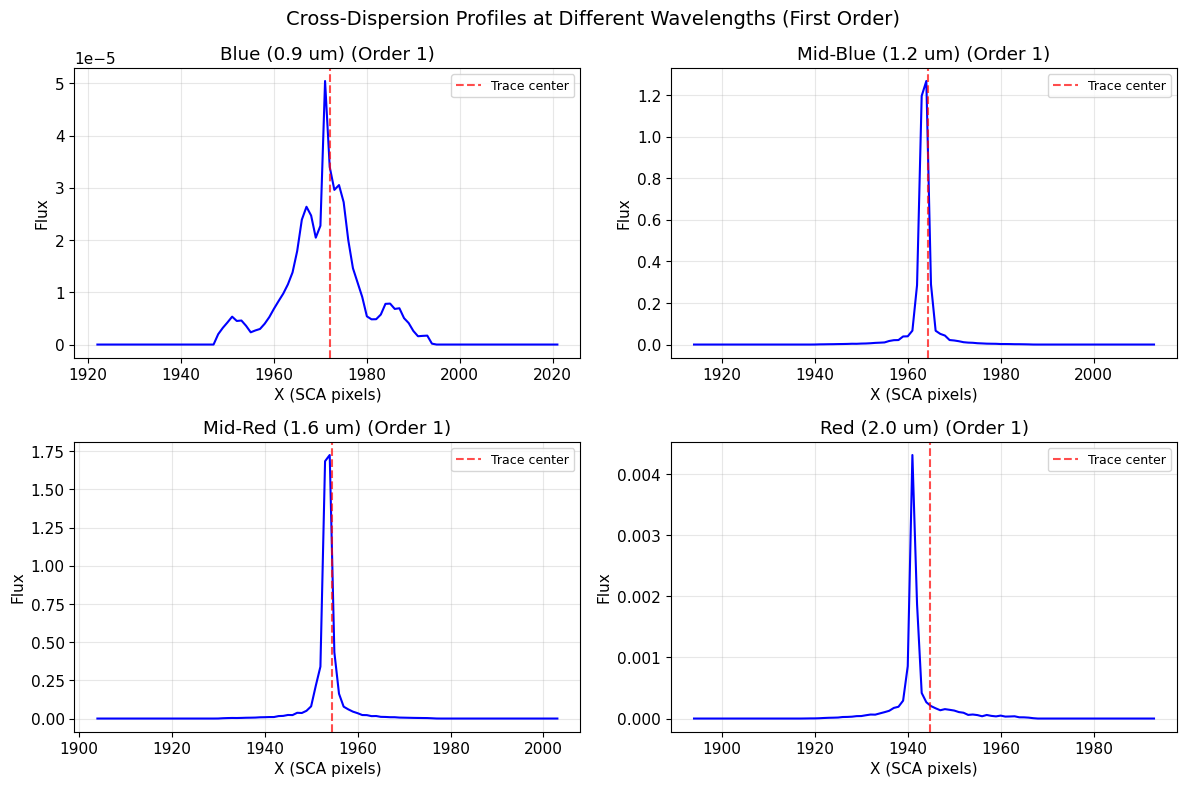

In [12]:
# Extract cross-dispersion profile at different wavelengths (using first order trace)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

wavelength_labels = ['Blue (0.9 um)', 'Mid-Blue (1.2 um)', 'Mid-Red (1.6 um)', 'Red (2.0 um)']
wavelength_values = [0.9, 1.2, 1.6, 2.0]  # microns

# Use first order trace for cross-sections
xsca_trace = traces['1']['x']
ysca_trace = traces['1']['y']

for ax, wl_um, label in zip(axes.flatten(), wavelength_values, wavelength_labels):
    # Find trace position for this wavelength
    idx = int((wl_um - float(wavelengths[0])) / (float(wavelengths[-1]) - float(wavelengths[0])) * (N_WAVELENGTH - 1))
    idx = max(0, min(idx, N_WAVELENGTH - 1))
    
    x_center = float(xsca_trace[idx])
    y_center = float(ysca_trace[idx])
    
    # Extract cross-dispersion slice (along X at fixed Y)
    y_idx = int(y_center)
    if 0 <= y_idx < 4088:
        profile = np.array(output[y_idx, :])
        x_pixels = np.arange(len(profile))
        
        # Only plot around the peak
        x_lo = max(0, int(x_center) - 50)
        x_hi = min(4088, int(x_center) + 50)
        
        ax.plot(x_pixels[x_lo:x_hi], profile[x_lo:x_hi], 'b-', linewidth=1.5)
        ax.axvline(x_center, color='r', linestyle='--', alpha=0.7, label=f'Trace center')
        ax.set_title(f'{label} (Order 1)')
        ax.set_xlabel('X (SCA pixels)')
        ax.set_ylabel('Flux')
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(alpha=0.3)

plt.suptitle('Cross-Dispersion Profiles at Different Wavelengths (First Order)', fontsize=14)
plt.tight_layout()
plt.show()

## Disperse Multiple Stars

Demonstrate dispersing multiple stars at different positions.

In [13]:
# Define multiple star positions and brightnesses
stars = [
    {'x': 1500.0, 'y': 1500.0, 'brightness': 1.0},
    {'x': 2000.0, 'y': 2000.0, 'brightness': 0.5},
    {'x': 2500.0, 'y': 1800.0, 'brightness': 0.75},
    {'x': 1800.0, 'y': 2500.0, 'brightness': 0.3},
]

print(f"Dispersing {len(stars)} stars through {len(ORDERS)} orders...")
print(f"Order efficiencies: {ORDER_EFFICIENCY}")

# Initialize output
output_multi = jnp.zeros((4088, 4088), dtype=jnp.float32)

t0 = time.time()
for i, star in enumerate(stars):
    for order in ORDERS:
        efficiency = ORDER_EFFICIENCY[order]
        flux = star_flux * star['brightness'] * efficiency
        output_multi = star_dispersers[order](
            star['x'], star['y'],
            wavelengths,
            flux,
            output_multi
        )
    print(f"  Star {i+1}: ({star['x']:.0f}, {star['y']:.0f}), brightness={star['brightness']:.2f}")

output_multi.block_until_ready()
elapsed = time.time() - t0

print(f"\nTotal time: {elapsed:.3f} seconds")
print(f"Per star (all orders): {elapsed/len(stars):.3f} seconds")
print(f"Total flux: {float(output_multi.sum()):.6f}")

Dispersing 4 stars through 3 orders...
Order efficiencies: {'0': 0.02, '1': 1.0, '2': 0.01}
  Star 1: (1500, 1500), brightness=1.00
  Star 2: (2000, 2000), brightness=0.50
  Star 3: (2500, 1800), brightness=0.75
  Star 4: (1800, 2500), brightness=0.30

Total time: 5.945 seconds
Per star (all orders): 1.486 seconds
Total flux: 10092.542969


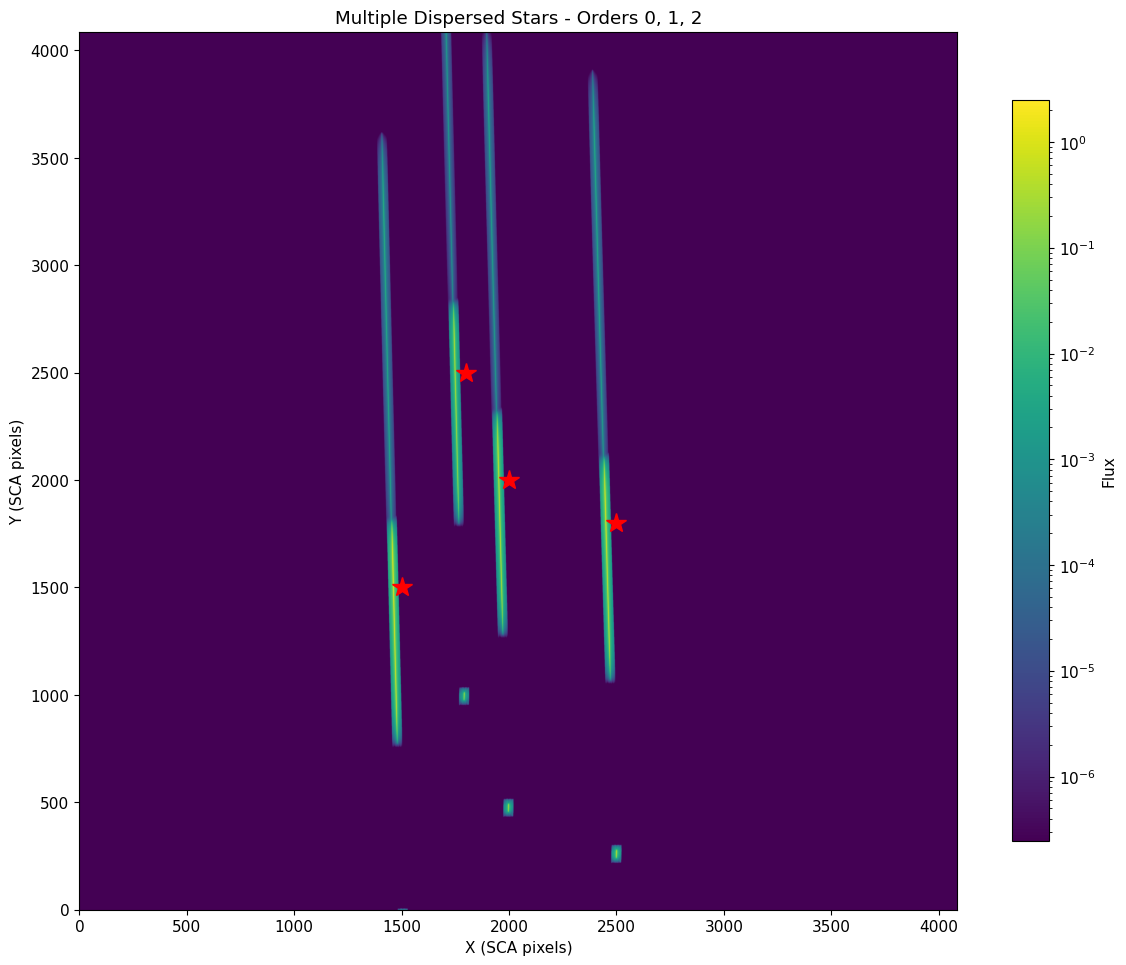

In [14]:
# Visualize multiple stars
fig, ax = plt.subplots(figsize=(12, 10))

# Add a small floor to make the full detector visible
floor = output_multi.max() * 1e-7
output_display = jnp.maximum(output_multi, floor)

im = ax.imshow(
    output_display,
    origin='lower',
    cmap='viridis',
    norm=LogNorm(vmin=float(floor), vmax=float(output_multi.max())),
)

# Mark star positions
for star in stars:
    ax.plot(star['x'], star['y'], 'r*', markersize=15)

ax.set_title(f'Multiple Dispersed Stars - Orders {", ".join(ORDERS)}')
ax.set_xlabel('X (SCA pixels)')
ax.set_ylabel('Y (SCA pixels)')
plt.colorbar(im, ax=ax, label='Flux', shrink=0.8)

plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated:

1. **Loading PSF payloads**: Using cached PSFs for fast startup (orders 0 and 1)
2. **Multi-order dispersion**: Dispersing through zeroth, first, and second orders
   - Order 0: Undispersed (2% efficiency)
   - Order 1: Primary dispersed spectrum (100% efficiency)
   - Order 2: Uses Order 1 PSFs (1% efficiency)
3. **Star dispersion**: Using `disperse_star_psf()` and `make_star_disperser()`
4. **Trace verification**: PSFs land exactly at optical model predicted positions
5. **Multiple stars**: Efficient dispersion of multiple stars through all orders

**Key points**:
- PSF shape varies with wavelength (diffraction limit)
- PSF lookup uses **undispersed** star position (per STPSF requirements)
- Each wavelength's PSF is deposited at its **dispersed** position from trace_beam
- Order efficiencies are simplified placeholders (2%, 100%, 1% for orders 0, 1, 2)
- JIT compilation provides speedup for repeated calls
- **Memory-efficient chunking**: Wavelengths are processed in chunks (default 1000) using `jax.lax.scan`, keeping peak memory at ~620 MB regardless of total wavelength count
- Flux is conserved when fully on detector